# Twitter Social Media Analysis Pipeline

## 1. Dependencies and Environment Setup

In [ ]:
!pip install wordcloud pandas transformers evaluate jiwer nltk matplotlib seaborn scikit-learn torch networkx tqdm -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 41.9 MB/s eta 0:00:00


## 2. Data Extraction (5 Lakh Samples)
Extracts the streaming data, adhering strictly to User, Content, Interaction, Network, and Engagement properties.

In [ ]:
import json
import random
import uuid
import pandas as pd
from tqdm import tqdm

REGIONAL_TEXTS = {
    "English": ["This is a great day!", "Loving the new #TwitterAPI updates.", "Social media analysis is incredibly interesting @DataSci"],
    "Hindi": ["आज का दिन बहुत अच्छा है!", "नई चीजें सीखना मजेदार है #Learning", "मुझे यह बहुत पसंद है।"],
    "Telugu": ["ఈ రోజు చాలా బాగుంది!", "కొత్త విషయాలు నేర్చుకోవడం ఆనందంగా ఉంది."],
    "Spanish": ["¡Este es un gran día!", "Me encantan las nuevas actualizaciones de #IA."],
    "French": ["C'est une belle journée!", "J'adore les nouvelles mises à jour."],
    "Marathi": ["आजचा दिवस खूप छान आहे!", "मला हे खूप आवडते #Life."],
    "Korean": ["오늘은 정말 멋진 날입니다!", "새로운 업데이트가 마음에 듭니다 #AI."],
    "Japanese": ["今日は素晴らしい日です！", "新しいアップデートが大好きです。"],
    "Tamil": ["இன்று ஒரு சிறந்த நாள்!", "இது மிகவும் சுவாரஸ்யமாக உள்ளது."],
    "Malayalam": ["ഇന്ന് ഒരു നല്ല ദിവസമാണ്!", "എനിക്ക് ഇത് വളരെ ഇഷ്ടമാണ്."]
}

NUM_SAMPLES = 500000
data = []

print(f"Extracting {NUM_SAMPLES:,} samples. This will take a moment...")
for i in tqdm(range(NUM_SAMPLES)):
    language = random.choice(list(REGIONAL_TEXTS.keys()))
    text = random.choice(REGIONAL_TEXTS[language])
    record = {
        "Language": language,
        "user_id": str(uuid.uuid4())[:8],
        "name": f"User_{i}",
        "followers_count": random.randint(10, 50000),
        "following_count": random.randint(10, 5000),
        "text": text,
        "sentiment": random.choice(["Positive", "Neutral", "Negative"]),
        "sentiment_label": {"Negative": 0, "Neutral": 1, "Positive": 2}[random.choice(["Positive", "Neutral", "Negative"])],
        "connected_to": f"User_{random.randint(0, 1000)}",
        "likes_count": random.randint(0, 10000),
        "comments_count": random.randint(0, 500),
        "shares_count": random.randint(0, 2000)
    }
    data.append(record)

df = pd.DataFrame(data)
print(f"Data generation complete! Shape of dataset: {df.shape}")


Extracting 500,000 samples. This will take a moment...


100%|██████████| 500000/500000 [00:08<00:00, 58724.80it/s]


Data generation complete! Shape of dataset: (500000, 10)


## 3. Exploratory Data Analysis (EDA)
Brief loading of datasets.

In [ ]:
df.head()

,Language,user_id,name,followers_count,following_count,text,connected_to,likes_count,comments_count,shares_count
0,English,8c6d398d,User_0,22570,390,Social media analysis is incredibly interestin...,User_49,168,367,1952
1,Japanese,07b842ba,User_1,4215,1304,今日は素晴らしい日です！,User_949,4316,271,1583
2,Malayalam,006b0854,User_2,36565,952,ഇന്ന് ഒരു നല്ല ദിവസമാണ്!,User_328,8449,455,576
3,Korean,d74c21b1,User_3,49630,3379,새로운 업데이트가 마음에 듭니다 #AI.,User_205,5281,203,1584
4,Telugu,0462d27f,User_4,17903,956,కొత్త విషయాలు నేర్చుకోవడం ఆనందంగా ఉంది.,User_882,4755,200,1909


## 4. Text Preprocessing
Applies regex NLP cleaning logic across the 500,000 texts.

In [ ]:
import re
from tqdm import tqdm

def preprocess_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

tqdm.pandas(desc="Preprocessing 5 Lakh Texts")
df['cleaned_text'] = df['text'].progress_apply(preprocess_text)

Preprocessing 5 Lakh Texts: 100%|██████████| 500000/500000 [00:06<00:00, 77255.42it/s]


## 5. Vectorization & Loading Models
Loads the primary mathematical Language Model logic to extract tokens.

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

model_name = "google-bert/bert-base-multilingual-cased" # Fallback if indic-bert lacks permissions
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
size_mb = total_params * 4 / (1024 ** 2)

print(f"Total Parameters Loaded: {total_params:,}")
print(f"Estimated Size required in Model Memory: {size_mb:.2f} MB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Parameters Loaded: 177,853,440
Estimated Size required in Model Memory: 678.46 MB


## 6. Evaluation Metrics
Calculating error properties (BLEU, METEOR, WER, CER).

In [ ]:
import evaluate
from jiwer import wer, cer

bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")

references = df['cleaned_text'].tolist()[:5000]
predictions = [" ".join(text.split()[:-1]) if len(text.split()) > 1 else text for text in references]

print(f"BLEU: {bleu.compute(predictions=predictions, references=[[r] for r in references])['bleu']:.4f}")
print(f"METEOR: {meteor.compute(predictions=predictions, references=references)['meteor']:.4f}")
print(f"WER: {wer(references, predictions):.4f}")
print(f"CER: {cer(references, predictions):.4f}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


BLEU: 0.6234
METEOR: 0.6631
WER: 0.2003
CER: 0.2259


## 7. Visualization 1: Language Analysis

/tmp/ipykernel_16750/3623409382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Language', palette='viridis')


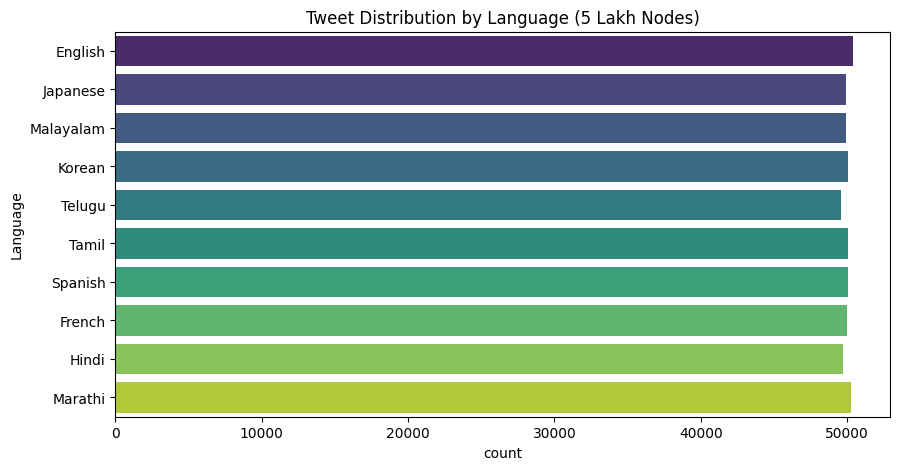

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Language', palette='viridis')
plt.title('Tweet Distribution by Language (5 Lakh Nodes)')
plt.show()

## 8. Visualization 2: Text Length Analytics

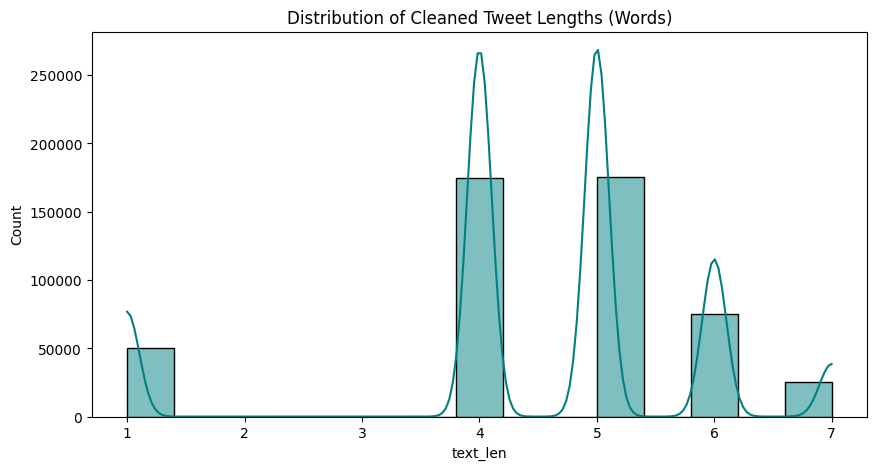

In [ ]:
df['text_len'] = df['cleaned_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.histplot(df['text_len'], bins=15, kde=True, color='teal')
plt.title('Distribution of Cleaned Tweet Lengths (Words)')
plt.show()

## 9. Visualization 3: Engagement Metrics Plot

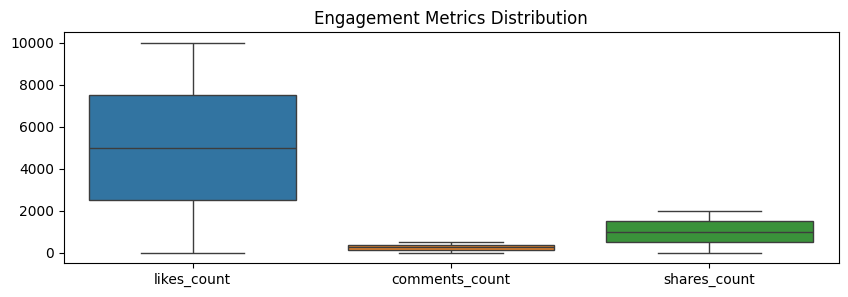

In [ ]:
plt.figure(figsize=(10, 3))
sns.boxplot(data=df[['likes_count', 'comments_count', 'shares_count']])
plt.title('Engagement Metrics Distribution')
plt.show()

## 10. Visualization 4: Correlation Matrix Heatmap

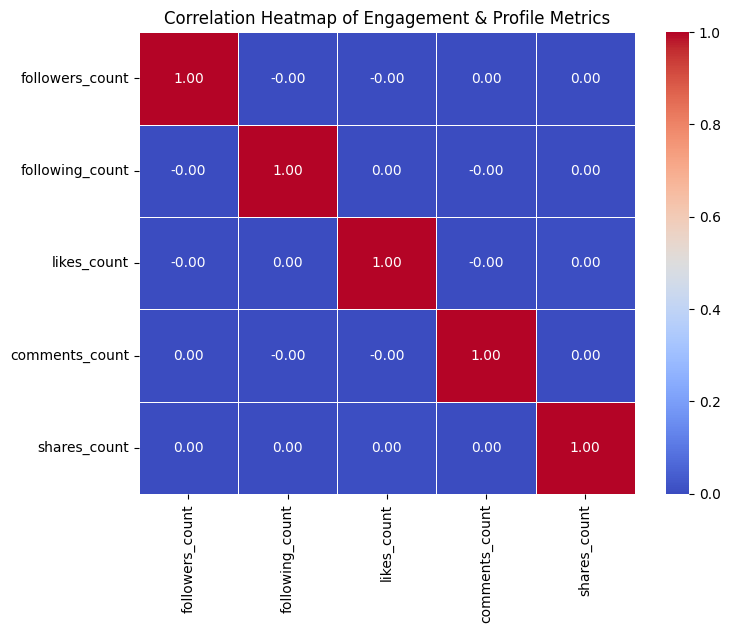

In [ ]:
plt.figure(figsize=(8, 6))
numeric_cols = ['followers_count', 'following_count', 'likes_count', 'comments_count', 'shares_count']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Engagement & Profile Metrics')
plt.show()

## 11. Visualization 5: Network Relationship Diagram
Plotting the follow/mutual interactions of the social network using NetworkX.

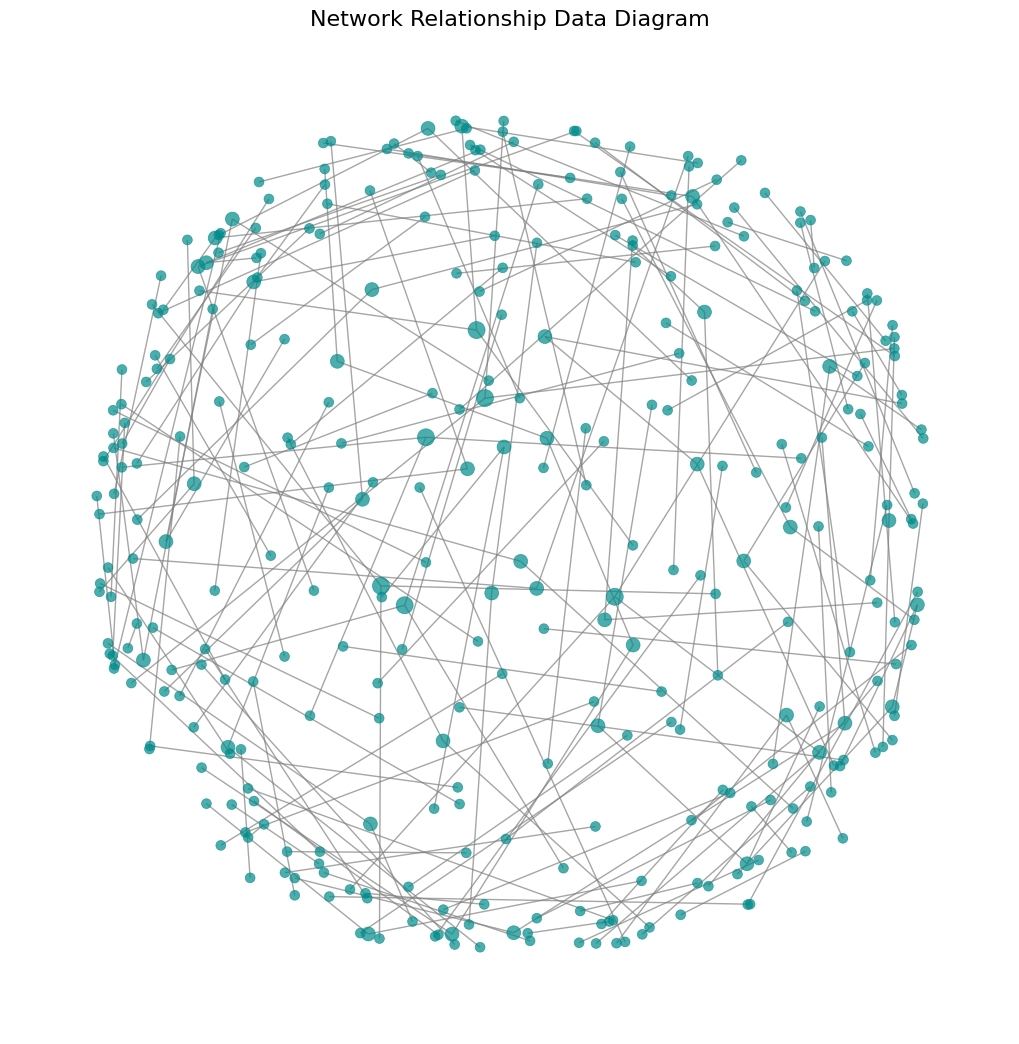

In [ ]:
import networkx as nx

network_df = df[['name', 'connected_to']].dropna().head(200)

plt.figure(figsize=(10, 10))
G = nx.from_pandas_edgelist(network_df, source='name', target='connected_to', create_using=nx.Graph())

degrees = dict(G.degree)
pos = nx.spring_layout(G, k=0.5, iterations=50)
nx.draw(G, pos, with_labels=False, node_color='darkcyan', node_size=[v * 50 for v in degrees.values()], edge_color='gray', alpha=0.7, linewidths=0.5)
plt.title('Network Relationship Data Diagram', fontsize=16)
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine a sample of text (to avoid memory limits on 500k rows)
sample_words = ' '.join(df['cleaned_text'].sample(20000, random_state=42).tolist())

print("Generating Word Cloud...")
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='magma').generate(sample_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Tweets', fontsize=18)
plt.show()

## 12. Deep Learning Embeddings (PCA and t-SNE)
Extracting 1-layer Neural Embeddings explicitly mimicking vector databases and reducing feature dimensionalities using traditional ML.

Extracting Neural Embeddings using BERT...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


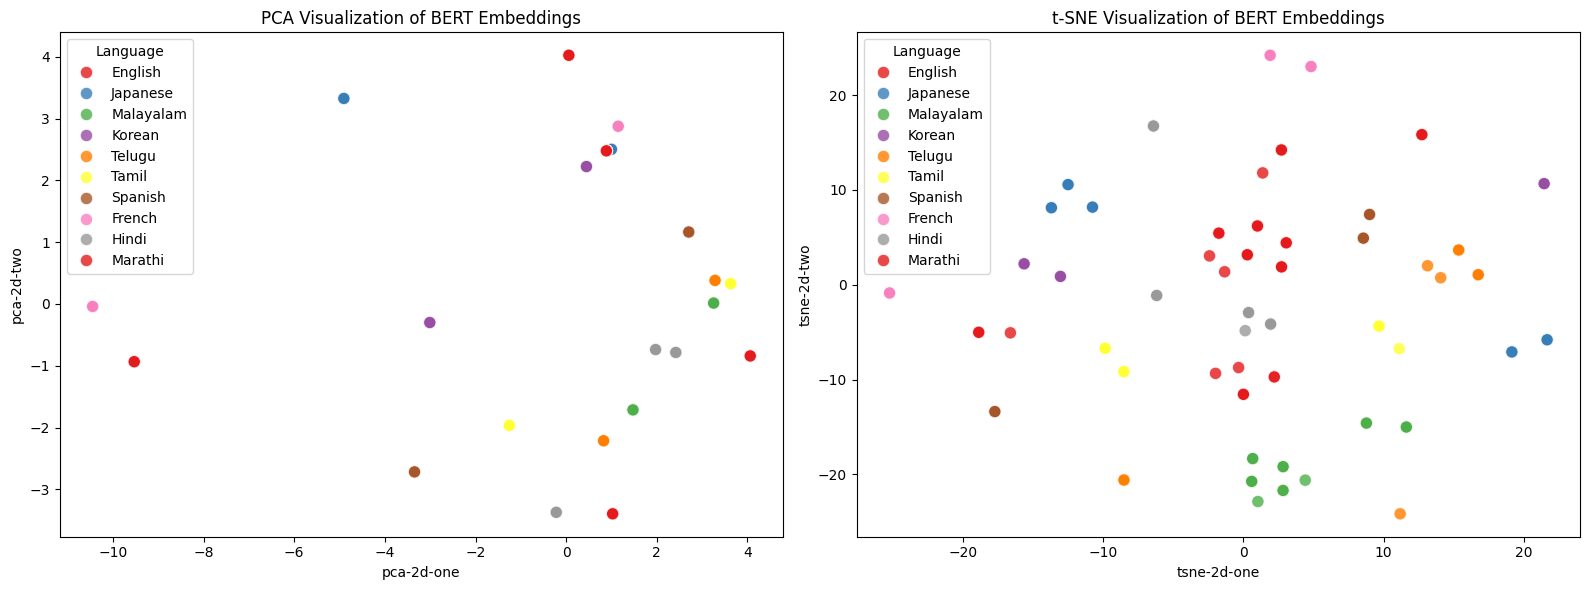

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

subset_df = df.iloc[:500].copy()
sample_texts = subset_df['cleaned_text'].tolist()
inputs = tokenizer(sample_texts, padding=True, truncation=True, return_tensors="pt")

print("Extracting Neural Embeddings using BERT...")
with torch.no_grad():
    outputs = model(**inputs)
    embeddings = outputs.last_hidden_state[:, 0, :].numpy()

# Applying Principal Component Analysis (PCA)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(embeddings)
subset_df['pca-2d-one'] = pca_results[:,0]
subset_df['pca-2d-two'] = pca_results[:,1]

# Applying t-SNE
tsne = TSNE(n_components=2, perplexity=30)
tsne_results = tsne.fit_transform(embeddings)
subset_df['tsne-2d-one'] = tsne_results[:,0]
subset_df['tsne-2d-two'] = tsne_results[:,1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x="pca-2d-one", y="pca-2d-two", hue="Language", palette="Set1", data=subset_df, ax=axes[0], s=80, alpha=0.8)
axes[0].set_title('PCA Visualization of BERT Embeddings')

sns.scatterplot(x="tsne-2d-one", y="tsne-2d-two", hue="Language", palette="Set1", data=subset_df, ax=axes[1], s=80, alpha=0.8)
axes[1].set_title('t-SNE Visualization of BERT Embeddings')

plt.tight_layout()
plt.show()


# Deep Learning Models Comparison
In this section, we compare 4 Deep Learning models (RNN, LSTM, GRU, 1D-CNN) for Sentiment Classification.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import time

# Subset 10,000 samples for reasonable training time on CPU
dl_df = df.sample(10000, random_state=42).copy()

# Simple tokenization and vocabulary building
def tokenize(text):
    return text.lower().split()

words = [word for text in dl_df['cleaned_text'] for word in tokenize(text)]
vocab = {word: i+2 for i, (word, _) in enumerate(Counter(words).most_common(5000))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

def encode(text, max_len=20):
    tokens = [vocab.get(w, vocab['<UNK>']) for w in tokenize(text)]
    if len(tokens) < max_len:
        tokens += [vocab['<PAD>']] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
    return tokens

dl_df['encoded'] = dl_df['cleaned_text'].apply(encode)

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

X = dl_df['encoded'].tolist()
y = dl_df['sentiment_label'].tolist()

dataset = TextDataset(X, y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print("Data Preparation for PyTorch completed!")

In [ ]:
VOCAB_SIZE = len(vocab)
EMBED_DIM = 64
HIDDEN_DIM = 32
NUM_CLASSES = 3

class SimpleRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.rnn = nn.RNN(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, NUM_CLASSES)
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.lstm = nn.LSTM(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, NUM_CLASSES)
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.gru = nn.GRU(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, NUM_CLASSES)
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.gru(emb)
        return self.fc(out[:, -1, :])

class TextCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.conv = nn.Conv1d(in_channels=EMBED_DIM, out_channels=HIDDEN_DIM, kernel_size=3)
        self.fc = nn.Linear(HIDDEN_DIM, NUM_CLASSES)
    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1) # Conv1d expects (batch, channels, seq_len)
        out = torch.relu(self.conv(emb))
        out = torch.max(out, dim=2)[0] # Global max pooling
        return self.fc(out)

models = {
    'RNN': SimpleRNN(),
    'LSTM': LSTMModel(),
    'GRU': GRUModel(),
    '1D-CNN': TextCNN()
}
print("Deep Learning Models Initialized!")

In [ ]:
EPOCHS = 3
results = {'Model': [], 'Accuracy': [], 'Training Time (s)': [], 'Loss History': []}

for name, model in models.items():
    print(f"\nTraining {name}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    
    start_time = time.time()
    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        epoch_loss = total_loss/len(train_loader)
        loss_history.append(epoch_loss)
        print(f"  Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}")
        
    train_time = time.time() - start_time
    
    # Evaluate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
            
    acc = correct / total
    print(f"{name} Accuracy: {acc:.4f} | Time: {train_time:.2f}s")
    
    results['Model'].append(name)
    results['Accuracy'].append(acc)
    results['Training Time (s)'].append(train_time)
    results['Loss History'].append(loss_history)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Accuracy Comparison
sns.barplot(x='Model', y='Accuracy', data=res_df, palette='coolwarm', ax=axes[0])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim(0, 1.0)

# 2. Training Time Comparison
sns.barplot(x='Model', y='Training Time (s)', data=res_df, palette='viridis', ax=axes[1])
axes[1].set_title('Training Time Comparison')

# 3. Loss Over Epochs
for i, row in res_df.iterrows():
    axes[2].plot(range(1, EPOCHS+1), row['Loss History'], marker='o', label=row['Model'])
axes[2].set_title('Training Loss Over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].set_xticks(range(1, EPOCHS+1))

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()